In [1]:
!pip install shap

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

In [3]:
from google.colab import files

uploaded = files.upload()

Saving dependency_dataset.csv to dependency_dataset.csv


In [4]:
df = pd.read_csv(
    "dependency_dataset.csv"
)

In [6]:
df.head()

df.columns.tolist()

['age',
 'gender',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'stress_level',
 'academic_work_impact',
 'addiction_level',
 'addicted_label',
 'weekend_usage_difference',
 'sleep_deficit',
 'notification_intensity',
 'weekend_overuse',
 'DEI',
 'DEI_Category',
 'attention_score',
 'attention_category',
 'addiction_level_num',
 'NDI',
 'dependency_category',
 'attention_inverse',
 'Aggression_Risk',
 'Aggression_Category']

In [7]:
features = [

    'notifications_per_day',

    'app_opens_per_day',

    'daily_screen_time_hours',

    'DEI',

    'attention_score',

    'NDI'

]

In [8]:
X = df[features]

y = df[
    'Aggression_Category'
]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

In [10]:
#Train Model
model = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [11]:
#Create SHAP Explainer
explainer = shap.TreeExplainer(
    model
)

In [12]:
#Generate SHAP Values
shap_values = explainer.shap_values(
    X_test
)

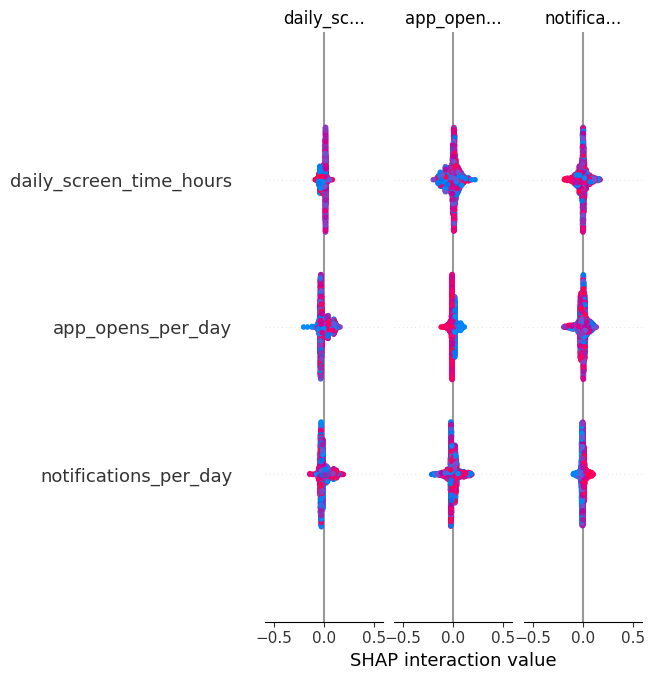

In [15]:
#SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_test
)

#Interpretation
#Red: High Feature Value
#Blue: Low Feature Value
#Features at top: Most Important

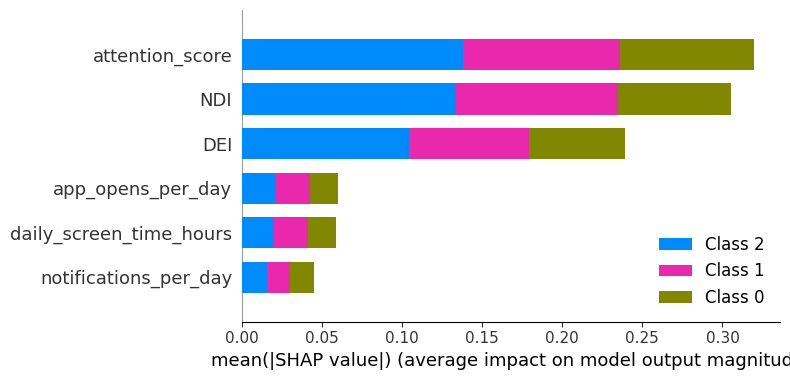

In [16]:
#Feature Importance Bar Plot
shap.summary_plot(

    shap_values,

    X_test,

    plot_type="bar"

)

In [20]:
#Single Prediction Explanation

X_test.iloc[0]



,970
notifications_per_day,65.000000
app_opens_per_day,117.000000
daily_screen_time_hours,7.450000
DEI,40.026465
attention_score,71.912061
NDI,43.400856


<class 'numpy.ndarray'>
(1500, 6, 3)


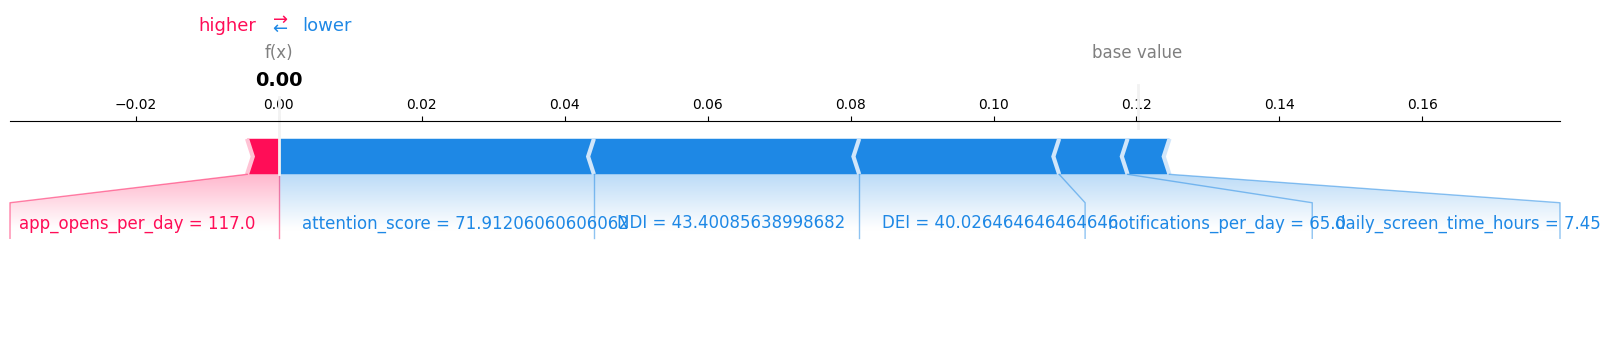

In [23]:
# Check shape first
print(type(shap_values))
print(np.array(shap_values).shape)

# Force plot for first class and first test sample
sample_idx = 0

shap.force_plot(
    explainer.expected_value[0],
    shap_values[:, :, 0][sample_idx],
    X_test.iloc[sample_idx],
    matplotlib=True
)

In [24]:
#Explain High Aggression User


high_user = df[
    df['Aggression_Category']
    ==
    'High'
]

#Display:

high_user.head()

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,...,DEI,DEI_Category,attention_score,attention_category,addiction_level_num,NDI,dependency_category,attention_inverse,Aggression_Risk,Aggression_Category
4,25,1,9.96,5.92,3.42,5.27,6.21,136,177,12.55,...,78.841602,High,41.917519,Moderate,3,78.615810,High,58.082481,81.798630,High
17,35,0,10.52,5.83,3.71,5.17,5.25,144,138,11.55,...,80.581003,High,37.540699,Low,2,64.993808,Moderate,62.459301,78.369747,High
18,18,0,11.87,1.96,3.14,3.00,6.40,207,157,14.02,...,64.723665,Moderate,49.142900,Moderate,2,80.861067,High,50.857100,74.785239,High
19,24,2,11.72,3.69,2.17,4.61,4.76,169,137,13.48,...,77.390397,High,40.507881,Moderate,2,70.586034,High,59.492119,78.417959,High
32,35,2,9.18,5.67,2.95,1.58,6.44,190,99,11.24,...,70.062619,High,48.556214,Moderate,3,68.987747,High,51.443786,71.749500,High


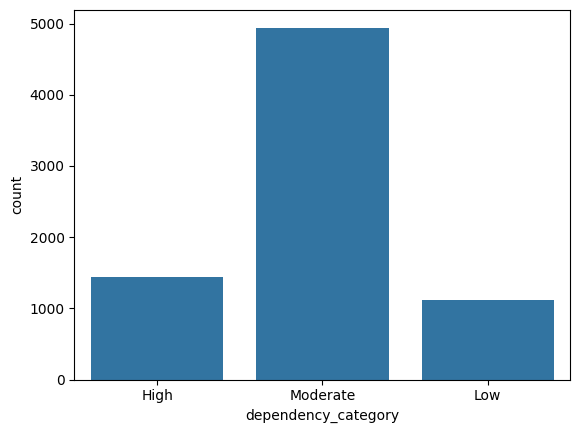

In [25]:
#Dependency Category Distribution
sns.countplot(
    data=df,
    x='dependency_category'
)

plt.show()

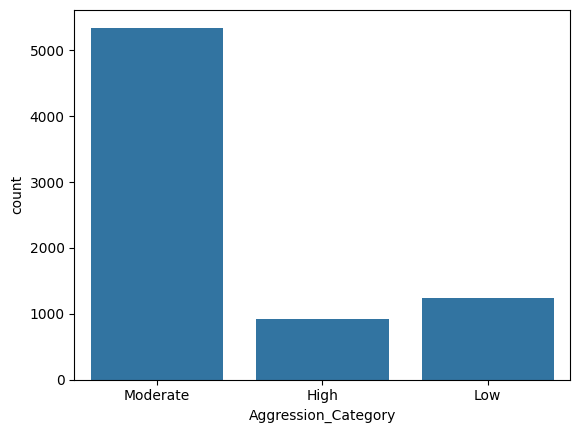

In [26]:
#Aggression Category Distribution
sns.countplot(
    data=df,
    x='Aggression_Category'
)

plt.show()

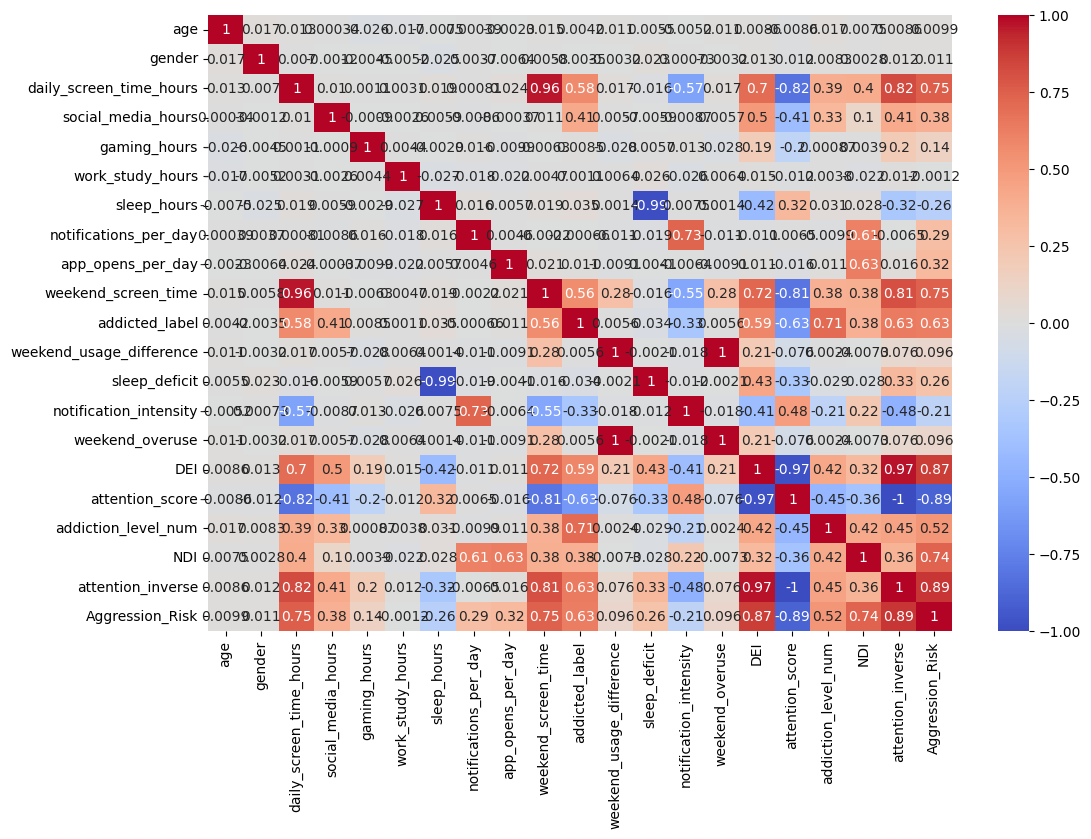

In [29]:
#Correlation Analysis
numeric_df = df.select_dtypes(
    include=['number']
)

corr = numeric_df.corr()

plt.figure(
    figsize=(12,8)
)

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True
)

plt.show()

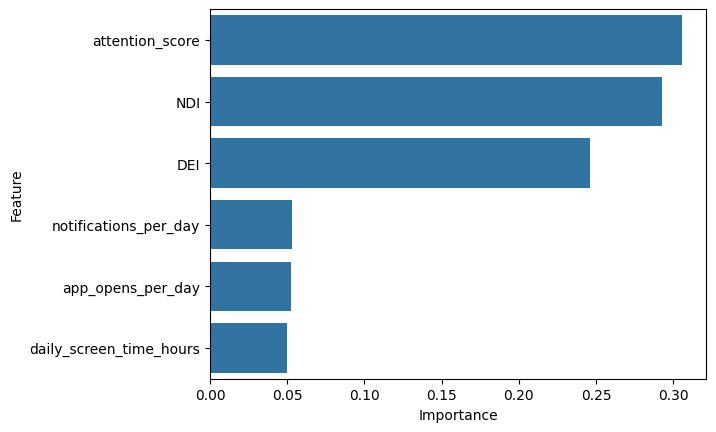

In [32]:
#Compare Feature Importance

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
    model.feature_importances_

})

importance = importance.sort_values(

    by='Importance',

    ascending=False

)

sns.barplot(

    data=importance,

    x='Importance',

    y='Feature'

)

plt.show()

Research Findings

1. NDI is among the strongest predictors of Aggression Risk.

2. High screen time increases Aggression Risk.

3. Lower attention scores contribute to higher aggression.

4. Frequent app openings influence dependency.

5. DEI contributes significantly to overall risk.

In [33]:
df.to_csv(
    "xai_dataset.csv",
    index=False
)

In [34]:
from google.colab import files

files.download(
    "xai_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>